Zoeken in map: C:\Projects\EPA133A-Advanced-Simulation-Group-1\EPA133a-G01-A3\experiment
Aantal gevonden CSV-bestanden: 5


C:\Users\mirte\AppData\Local\Temp\ipykernel_26412\425955815.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Scenario', y='Average Driving Time', data=full_df, palette='viridis')


Succes! De boxplot is gegenereerd.


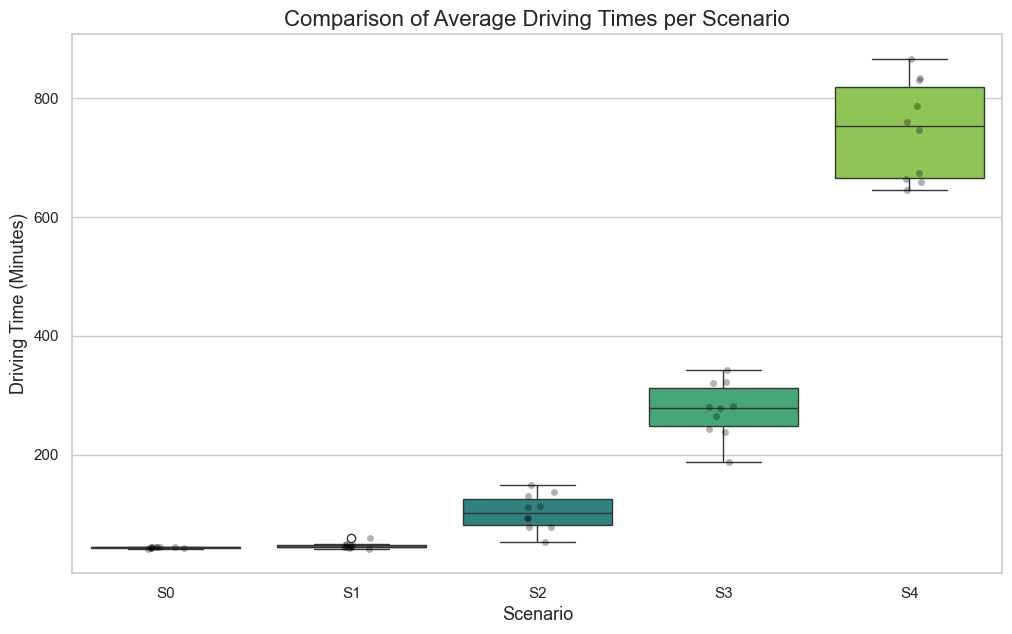

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os
import re

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [12, 7]

path = '../experiment'
all_files = glob.glob(os.path.join(path, "average_driving_times_scenario*.csv"))

df_list = []

for filename in all_files:
    match = re.search(r'scenario(\d+)', filename)
    if match:
        scenario_num = int(match.group(1))
        df = pd.read_csv(filename)
        df['Scenario'] = f'S{scenario_num}'
        df['Scenario_Int'] = scenario_num
        df_list.append(df)

if df_list:
    full_df = pd.concat(df_list, ignore_index=True).sort_values('Scenario_Int')

    plt.figure()
    sns.boxplot(x='Scenario', y='Average Driving Time', data=full_df, palette='viridis')
    sns.stripplot(x='Scenario', y='Average Driving Time', data=full_df, color='black', alpha=0.3, jitter=True)

    plt.title('Comparison of Average Driving Times per Scenario', fontsize=16)
    plt.ylabel('Driving Time (Minutes)', fontsize=13)
    plt.xlabel('Scenario', fontsize=13)

    save_path = '../img/boxplot_scenarios.png'
    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    plt.savefig(save_path, dpi=300)

    plt.show()
